# Setup
## Importowanie Bibliotek

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

## Pomocne Funkcje

In [5]:
def boxplot(df, column_name):
    """
    Displays a boxplot of the choosen column to show its distribution.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
    Returns:
        None. Displays the bar chart.
    """
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column_name].dropna(), color='lightgreen') # as you can see, you can use sns and plt at the same time
    plt.title(f'Distribution of {column_name} (boxplot)')
    plt.xlabel(column_name)

    plt.show()

def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=False)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()


def one_hot_encode_column(dataframe, column_name):
    return pd.get_dummies(dataframe, columns=[column_name], prefix=column_name)

def log_transform(dataframe, column_name):
    return np.log1p(dataframe[column_name])

def fill_with_median_in_a_group(dataframe, grouping_column_name, target_column_name):
    return dataframe.groupby([grouping_column_name])[target_column_name].transform(lambda x: x.fillna(x.median()))

def categorical_and_survived(df, categorical_column):
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=categorical_column, y='Survived', palette='Set2')
    plt.title(f'Survived by {categorical_column}')
    plt.xlabel(categorical_column)
    plt.ylabel('Survived')
    plt.tight_layout()
    plt.show()

def plot_numeric_histogram(df, column_name):
    """
    Plots a histogram for the specified column in the DataFrame,
    and adds vertical lines for the mean and median.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the column to plot.
    Returns:
        None. Displays the histogram.
    """

    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Ładowanie Danych

In [6]:
environments = ['Local', 'Colab']
environment = 'Colab'
if environment not in environments:
    print("Environment Invalid!")
elif environment == 'Local':
    base_path = Path("01_przetwarzanie_wizualizacja_danych") # change to path folder with data
    titanic_df = pd.read_csv( base_path / 'titanic.csv', index_col='PassengerId')
    print(titanic_df)
elif environment == 'Colab':
    from google.colab import drive # remove the cell if not using colab
    drive.mount('/content/drive')
    base_path = Path("./drive/MyDrive/Solvro/")
    titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
    print(titanic_df)

Mounted at /content/drive
             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry  

# Analiza
## Istotność Kolumn
Moi kandydaci na ważne kolumny:
* Survived - to co predykujemy
* Pclass - bogacze vs biedni
* Sex - "Najpierw kobiety i dzieci"
* Age - witalność może mieć wpływ na przetrwanie
* SibSp / Parch - wpływ rozmiaru rodziny na przetrwanie
* Fare - aparat porównawczy wewnątrz danej Pclass (bogaci vs bogatsi)
* Cabin - numer kabiny (do ekstrakcji lokalizacji na pokładzie)
* Embarked - miejsce wejścia na pokład może korelować z innymi cechami pasażera

In [7]:
titanic_df = titanic_df.drop(columns=['Name', 'Ticket'])
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      793 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 69.6+ KB


## Ekstrakcja
Numer kabiny jako tako nie jest nam potrzebny, natomiast literka służąca jako prefix to lokalizacja na pokładzie gdzie znajdował się pokój, co może być interesujące w kontekście bliskości do raft ratunkowych.

*Cabin*:**C134** -> *Location*:**C**

In [8]:
titanic_df['Location'] = titanic_df['Cabin'].str[0]
titanic_df = titanic_df.drop('Cabin', axis='columns')
titanic_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      793 non-null    float64
 7   Embarked  889 non-null    object 
 8   Location  204 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 69.6+ KB


Wyodrębnienie SibSp i Parch jest trochę zbyt szczegółowe - chciałbym przeanalizować jakie szanse na przeżycie ma człowiek ze względu na dużą *rodzinę*

In [9]:
titanic_df['Family'] = titanic_df['Parch'] + titanic_df['SibSp']
titanic_df = titanic_df.drop('Parch', axis='columns')
titanic_df = titanic_df.drop('SibSp', axis='columns')
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   Fare      793 non-null    float64
 5   Embarked  889 non-null    object 
 6   Location  204 non-null    object 
 7   Family    891 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 62.6+ KB


Czysto optymalizacyjnie, zamienię kolumnę 'Sex' na 'IsMale' z wartością typu bool:
* True -> memszczyzna
* False -> kombieta

In [10]:
titanic_df['IsMale'] = titanic_df['Sex'] == 'male'
titanic_df = titanic_df.drop('Sex', axis='columns')
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       714 non-null    float64
 3   Fare      793 non-null    float64
 4   Embarked  889 non-null    object 
 5   Location  204 non-null    object 
 6   Family    891 non-null    int64  
 7   IsMale    891 non-null    bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 56.6+ KB


## Braki w Wartościach

In [11]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Age,177
Fare,98
Embarked,2
Location,687
Family,0
IsMale,0


### Dystrybucja Wieku
Wiek:
* duży słupek najmłodszych
* dzwon wieku osób z centrum w ~25 lat
* długi ogon boomerów

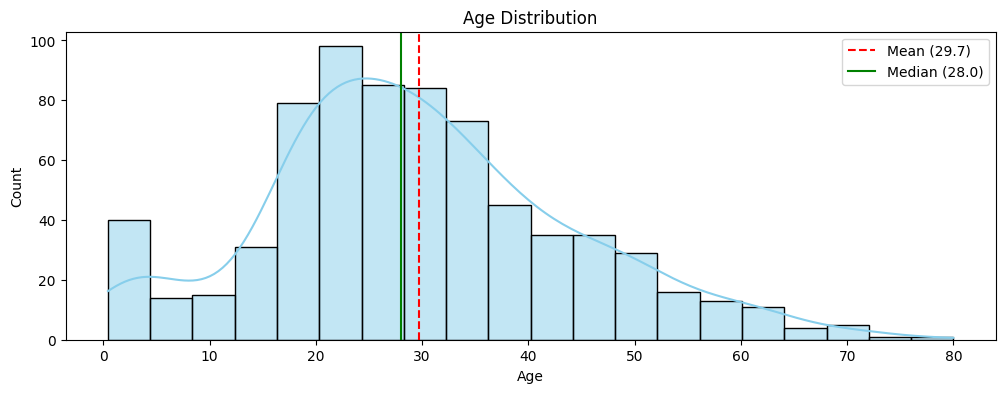

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


# Turn this to function and use for fare
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

age = titanic_df['Age']
age_cleaned = age.dropna()

mean_age = age_cleaned.mean()
median_age = age_cleaned.median()

sns.histplot(age_cleaned, kde=True, ax=axes, color='skyblue')
axes.axvline(mean_age, color='red', linestyle='--', label=f'Mean ({mean_age:.1f})')
axes.axvline(median_age, color='green', linestyle='-', label=f'Median ({median_age:.1f})')
axes.set_title('Age Distribution')
axes.legend()

Podrążmy to trochę!
Uważam, iż `Age` może ładnie sie korelować z wartością `Pclass` albo `Fare`, gdyż wraz z wiekiem człowiek często jest bardziej majętny.
Dokonam analizy wieku przez pryzmat `Pclass`y

In [13]:
print(titanic_df['Pclass'].unique())

[3 1 2]


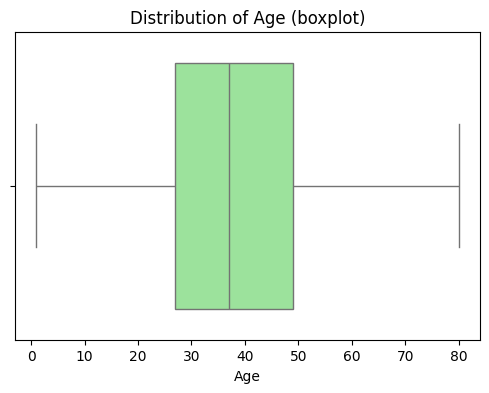

In [14]:
boxplot(titanic_df[titanic_df['Pclass'] == 1], "Age")

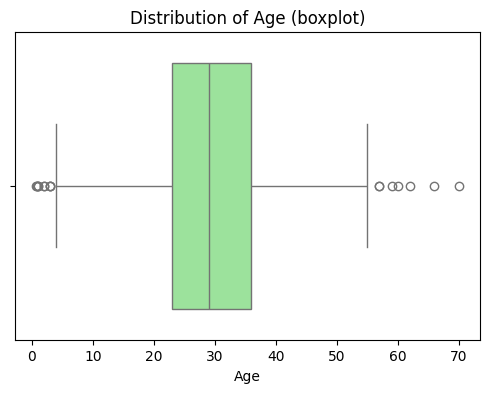

In [15]:
boxplot(titanic_df[titanic_df['Pclass'] == 2], "Age")

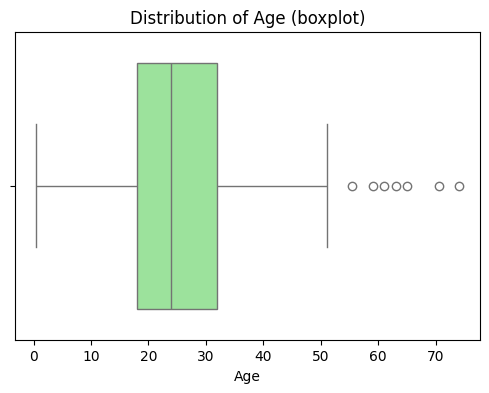

In [16]:
boxplot(titanic_df[titanic_df['Pclass'] == 3], "Age")

Mimo trochę overlappu, moja hipoteza się sprawdziła: `Age` rośnie tym wyższa klasa (niższa `Pclass`)
Uważam, iż najlepiej jest to załatwić medianą danej grupy `Pclass`:

In [17]:
titanic_df['Age'] = fill_with_median_in_a_group(titanic_df, 'Pclass', 'Age')
titanic_df['Age'].isna().sum()

np.int64(0)

### Dystrybucja Lokacji na Pokładzie
Mega dużo danych nam brakuje (77%!)

In [18]:
titanic_df['Location'].isna().mean() * 100

np.float64(77.10437710437711)

Biorąc pod uwagę ten masywny brak danych, najlepszym rozwiązaniem jest utworzenie oddzielnej kategorii dla niezidentifikowanej lokalizacji pokoju

In [19]:
registered_locations = titanic_df['Location'].unique()
unspecified_dummy_location = 'U'
if unspecified_dummy_location not in registered_locations:
  titanic_df['Location'] = titanic_df['Location'].fillna(unspecified_dummy_location)
titanic_df['Location'].unique()

array(['U', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [20]:
titanic_df['Location'].isna().sum()

np.int64(0)

### Dystrybucja Ceny Biletu (Fare)
Dystrybucje cen biletu (rozpatrzone wewnątrz danej Pclass'y) są asymetryczne (tak jak wiek)

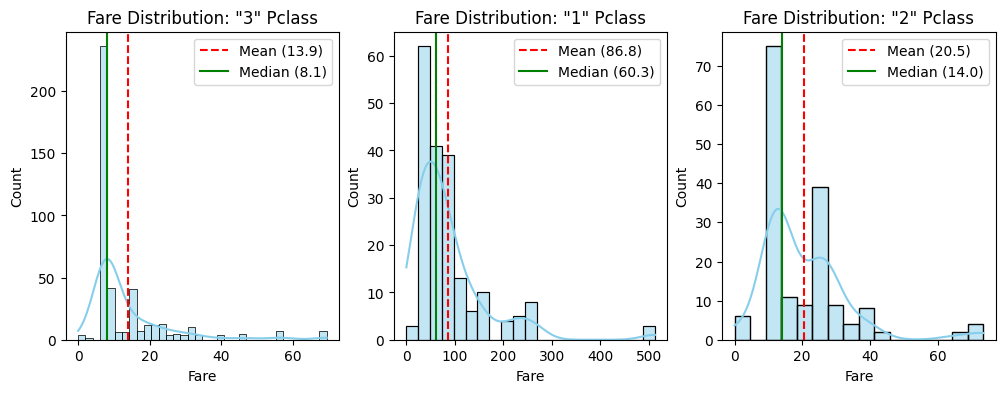

In [21]:
fig, axes = plt.subplots(1, len(titanic_df['Pclass'].unique()), figsize=(12, 4))
index = 0
for passenger_class in titanic_df['Pclass'].unique():
  fare = titanic_df[titanic_df['Pclass'] == passenger_class] # filter this shyt

  fare = fare['Fare']
  fare_cleaned = fare.dropna()

  mean_fare = fare_cleaned.mean()
  median_fare = fare_cleaned.median()

  sns.histplot(fare_cleaned, kde=True, ax=axes[index], color='skyblue')
  axes[index].axvline(mean_fare, color='red', linestyle='--', label=f'Mean ({mean_fare:.1f})')
  axes[index].axvline(median_fare, color='green', linestyle='-', label=f'Median ({median_fare:.1f})')
  axes[index].set_title(f'Fare Distribution: \"{passenger_class}\" Pclass')
  axes[index].legend()
  index+=1

Zatem tak samo jak przy wieku, do uzupełnienia danych użyjemy metody medianowej

In [22]:
titanic_df['Fare'] = fill_with_median_in_a_group(titanic_df, 'Pclass', 'Fare')

titanic_df['Fare'].isna().sum()

np.int64(0)

### Miejsce Wejścia Na Pokład (Embarked)

In [23]:
print(titanic_df['Embarked'].unique())
print(titanic_df[titanic_df['Embarked'].isna()])

['S' 'C' 'Q' nan]
             Survived  Pclass   Age  Fare Embarked Location  Family  IsMale
PassengerId                                                                
62                  1       1  38.0  80.0      NaN        B       0   False
830                 1       1  62.0  80.0      NaN        B       0   False


To są jedyni pasażerowie z niewiadomą wartością `Embarked`.
Uważam, iż poprzez analizę wartości `Fare` na tle `Embarked` jestem w stanie poprawnie zgadnąć brakujące wartości

In [24]:
summary_stats = titanic_df.groupby('Embarked')['Fare'].agg(
    ['count', 'mean', 'median']
)
print(summary_stats)

          count       mean   median
Embarked                           
C           168  58.901415  29.7000
Q            77  12.963855   7.8292
S           644  26.771744  13.0000


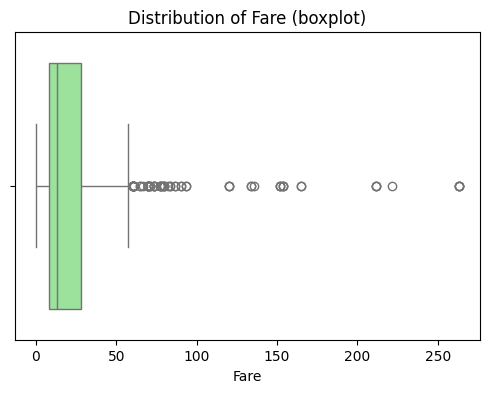

In [25]:
boxplot(titanic_df[titanic_df['Embarked'] == 'S'], "Fare")

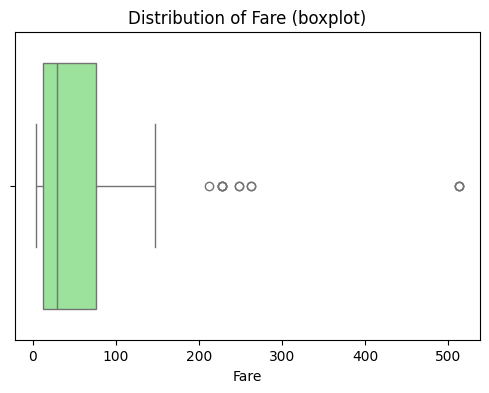

In [26]:
boxplot(titanic_df[titanic_df['Embarked'] == 'C'], "Fare")

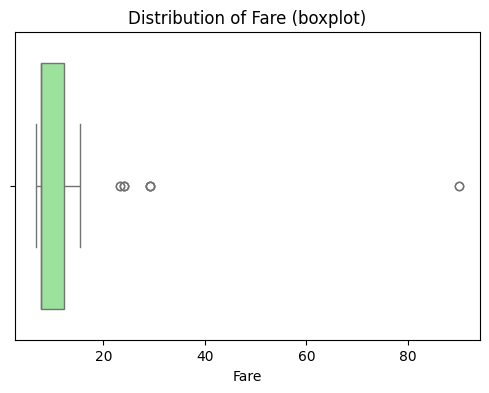

In [27]:
boxplot(titanic_df[titanic_df['Embarked'] == 'Q'], "Fare")

Co boxploty nam mówią:
* Wiekszość pasażerów z lokalizacji `Q` kupiło bilet poniżej $20                    -> *nie pasuje* :(
* Wiekszość pasażerów z lokalizacji `C` kupiło bilet w granicach $5 - $90           -> *2+dobrze* :>>>
* Wiekszość pasażerów z lokalizacji `S` kupiło bilet w granicach $0 - $35           -> *nie pasuje* :(

A zatem uważam, iż najlepiej jest uzupełnić wartości portem 'C'.

In [28]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('C')

Nie mamy już braków:

In [29]:
titanic_df.isna().sum()  # Returns the count of NaNs for each column

,0
Survived,0
Pclass,0
Age,0
Fare,0
Embarked,0
Location,0
Family,0
IsMale,0


## Typy Danych

In [30]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       891 non-null    float64
 3   Fare      891 non-null    float64
 4   Embarked  891 non-null    object 
 5   Location  891 non-null    object 
 6   Family    891 non-null    int64  
 7   IsMale    891 non-null    bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 56.6+ KB


Jeśli Survive ma być wartością logiczną, to zamiast int64 może być wartością typu bool

In [31]:
titanic_df['Survived'] = titanic_df['Survived'].astype(bool)
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    bool   
 1   Pclass    891 non-null    int64  
 2   Age       891 non-null    float64
 3   Fare      891 non-null    float64
 4   Embarked  891 non-null    object 
 5   Location  891 non-null    object 
 6   Family    891 non-null    int64  
 7   IsMale    891 non-null    bool   
dtypes: bool(2), float64(2), int64(2), object(2)
memory usage: 50.5+ KB


'Pclass', 'Embarked' & 'Location' to wartosci kategoryzujace o skończenie małym zakresie wartości, idealne dla *category* typu danych

In [32]:
titanic_df['Pclass'] = titanic_df['Pclass'].astype("category")
titanic_df['Location'] = titanic_df['Location'].astype("category")
titanic_df['Embarked'] = titanic_df['Embarked'].astype("category")
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    bool    
 1   Pclass    891 non-null    category
 2   Age       891 non-null    float64 
 3   Fare      891 non-null    float64 
 4   Embarked  891 non-null    category
 5   Location  891 non-null    category
 6   Family    891 non-null    int64   
 7   IsMale    891 non-null    bool    
dtypes: bool(2), category(3), float64(2), int64(1)
memory usage: 32.8 KB


Sprawdzę teraz czy wszystkie wartosci column Age lub Fare mozna przecastować na integery

In [33]:
if (titanic_df['Age'].dropna() % 1 == 0).all():
  print("Można!")
else:
  print("Nie można!")
  print(titanic_df[titanic_df['Age'] % 1 != 0])

Nie można!
             Survived Pclass    Age      Fare Embarked Location  Family  \
PassengerId                                                               
58              False      3  28.50    7.2292        C        U       0   
79               True      2   0.83   29.0000        S        U       2   
112             False      3  14.50   14.4542        C        U       1   
117             False      3  70.50    7.7500        Q        U       0   
123             False      2  32.50   30.0708        C        U       1   
124              True      2  32.50   13.0000        S        E       0   
149             False      2  36.50   26.0000        S        F       2   
153             False      3  55.50    8.0500        S        U       0   
154             False      3  40.50   14.5000        S        U       2   
204             False      3  45.50    7.2250        C        U       0   
228             False      3  20.50    7.2500        S        U       0   
297           

In [34]:
if (titanic_df['Fare'].dropna() % 1 == 0).all():
  print("Można!")
else:
  print("Nie można!")
  print(titanic_df[titanic_df['Fare'] % 1 != 0])

Nie można!
             Survived Pclass   Age     Fare Embarked Location  Family  IsMale
PassengerId                                                                  
1               False      3  22.0   7.2500        S        U       1    True
2                True      1  38.0  71.2833        C        C       1   False
3                True      3  26.0   7.9250        S        U       0   False
4                True      1  35.0  53.1000        S        C       1   False
5               False      3  35.0   8.0500        S        U       0    True
...               ...    ...   ...      ...      ...      ...     ...     ...
884             False      2  28.0  10.5000        S        U       0    True
885             False      3  25.0   7.0500        S        U       0    True
886             False      3  39.0   8.0500        Q        U       5   False
889             False      3  24.0  23.4500        S        U       3   False
891             False      3  32.0   7.7500        Q 

*Jak nie można, to nie można*

Sprawdzę czy da się uszczuplić 'Family'

In [35]:
print(titanic_df['Family'].min())
print(titanic_df['Family'].max())

0
10


In [36]:
titanic_df['Family'] = titanic_df['Family'].astype("int8")
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    bool    
 1   Pclass    891 non-null    category
 2   Age       891 non-null    float64 
 3   Fare      891 non-null    float64 
 4   Embarked  891 non-null    category
 5   Location  891 non-null    category
 6   Family    891 non-null    int8    
 7   IsMale    891 non-null    bool    
dtypes: bool(2), category(3), float64(2), int8(1)
memory usage: 26.7 KB


## Encoding

Trudno doszukiwać się jakieś reguły w wartościach `Embarked`, a ilość możliwych wartości jest wystarczająco mała byśmy użyli one-hot encodingu.

In [37]:
titanic_df = one_hot_encode_column(titanic_df, 'Embarked')
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    bool    
 1   Pclass      891 non-null    category
 2   Age         891 non-null    float64 
 3   Fare        891 non-null    float64 
 4   Location    891 non-null    category
 5   Family      891 non-null    int8    
 6   IsMale      891 non-null    bool    
 7   Embarked_C  891 non-null    bool    
 8   Embarked_Q  891 non-null    bool    
 9   Embarked_S  891 non-null    bool    
dtypes: bool(5), category(2), float64(2), int8(1)
memory usage: 28.3 KB


Z `Location` zróbmy tak samo

In [38]:
titanic_df = one_hot_encode_column(titanic_df, 'Location')

I z `Pclass`

In [39]:
titanic_df = one_hot_encode_column(titanic_df, 'Pclass')

'Survived' oraz 'IsMale' jest już binary-encoded, Age, Fare i Family to dane numeryczne, więc jak na mnie to git

## Outliery

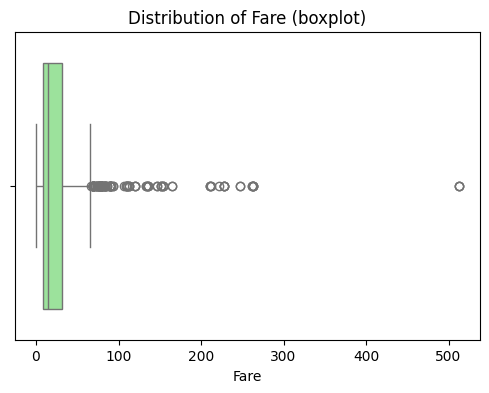

In [40]:
boxplot(titanic_df, 'Fare')

Jak widać, wartości `Fare` skupiają się w przedziale $(0;~40), istnieją przypadki z wiekszymi wartościami, tak jak outlier mający +$500.
Tak to przedstawia na histogramie:

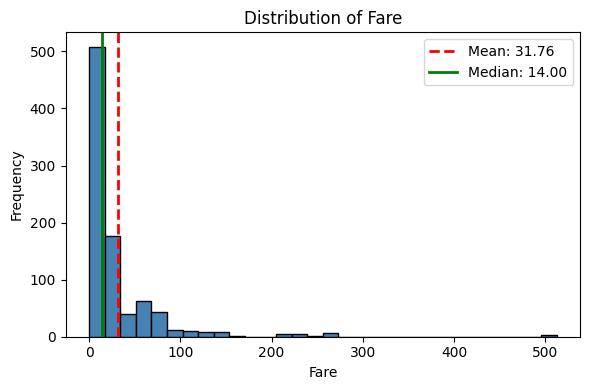

In [41]:
plot_numeric_histogram(titanic_df, 'Fare')

Mówiąc grzecznie - dystrybucja normalna to na pewno nie jest.
Ale gdybyśmy teraz dokonali transformacji logarytmicznej:

In [42]:
print(titanic_df['Fare'].head())
titanic_df['Fare'] = log_transform(titanic_df, 'Fare')
print(titanic_df['Fare'].head())

PassengerId
1     7.2500
2    71.2833
3     7.9250
4    53.1000
5     8.0500
Name: Fare, dtype: float64
PassengerId
1    2.110213
2    4.280593
3    2.188856
4    3.990834
5    2.202765
Name: Fare, dtype: float64


Dystrybucja wygląda następująco:

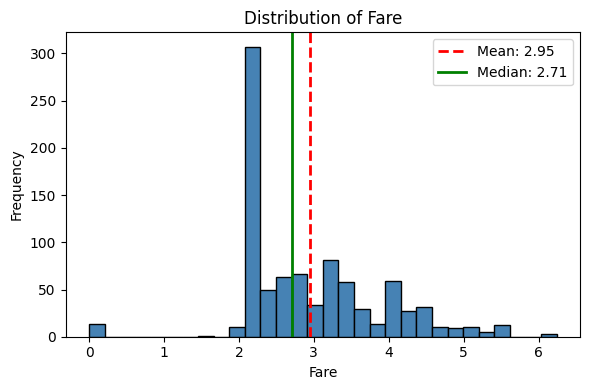

In [43]:
plot_numeric_histogram(titanic_df, 'Fare')

Bardziej porządnie!
## Troche wizualizacji danych

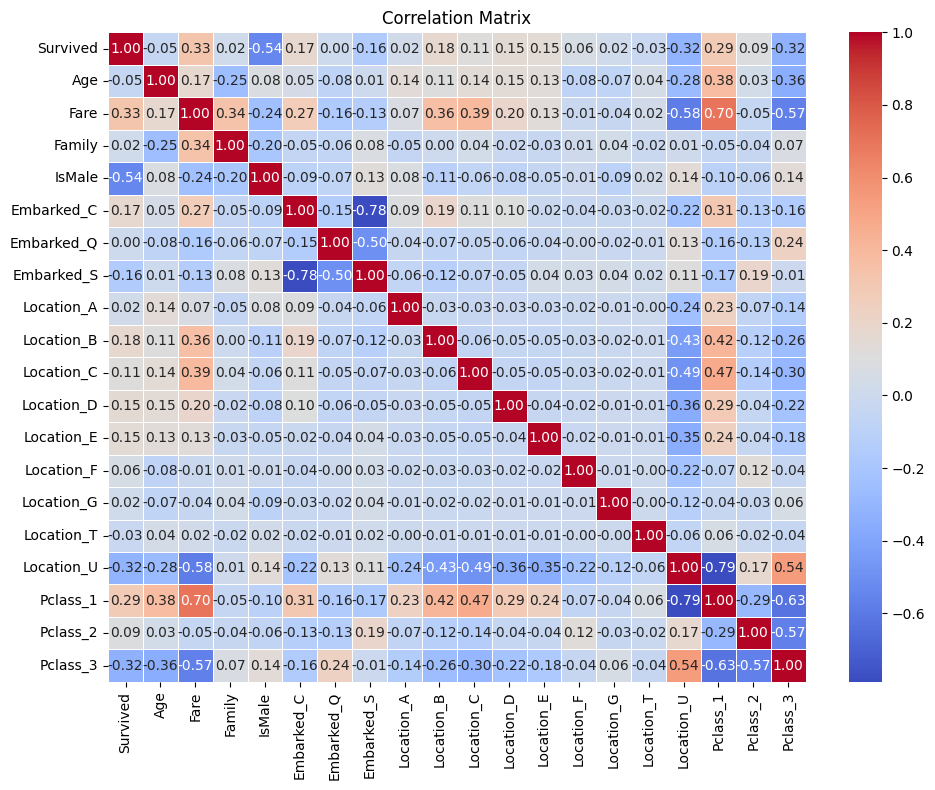

In [44]:
plot_correlation_matrix(titanic_df)

Macierz ukazuje nam następujące fakty odnośnie danych:
* Survived & IsMale: -0.54
    - jeśli jesteś memszczyzną to według modelu masz o wiele mniejsze szansy przeżycia
* Survived & Pclass: -0.34
    - im niższa wartość `Pclass` (im wyższa klasa) tym większa szansa na przeżycie
* Survived & Fare: 0.26
    - im droższy miałeś bilet, tym bardziej prawdopodone że przeżyłeś
* Survived & Location
    - najbardziej sprzyjająca lokalizacja do przetrwania katastrofy to 'B' (0.18)

Analiza ze względu na płeć
*Them clankers cooked with it!*

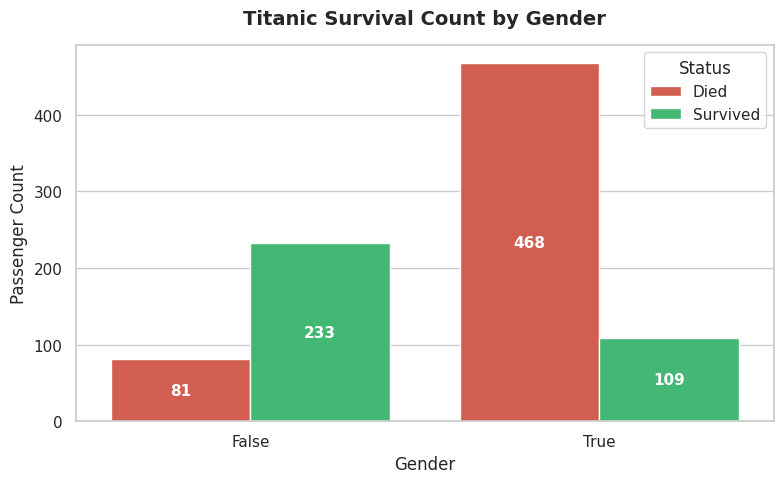

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Create count plot
ax = sns.countplot(
    data=titanic_df,
    x="IsMale",
    hue="Survived",
    palette={0: "#e74c3c", 1: "#2ecc71"},
)

# Customize labels
plt.title(
    "Titanic Survival Count by Gender", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Passenger Count", fontsize=12)
plt.legend(
    title="Status",
    labels=["Died", "Survived"],
    loc="upper right",
    frameon=True,
)

# Add numeric annotations inside bars
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(
            f"{height}",
            (p.get_x() + p.get_width() / 2.0, height / 2),
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

# Zapisanie Wartości

In [46]:
titanic_df.to_csv(base_path / 'titanic_analyzed.csv')